In [ ]:
import numpy as np
import cv2 
from google.colab.patches import cv2_imshow
import math
import matplotlib.pyplot as plt


Đọc ảnh trái và ảnh phải sử dụng thư viện OpenCV

In [ ]:
leftPath = "/content/drive/MyDrive/Stereo Matching/MiddleburyDataset/dificult condition/view1_d.png"
rightPath = "/content/drive/MyDrive/Stereo Matching/MiddleburyDataset/dificult condition/view5_d.png"

# leftPath = "/content/drive/MyDrive/Stereo Matching/MiddleburyDataset/normal condition/view1.png"
# rightPath = "/content/drive/MyDrive/Stereo Matching/MiddleburyDataset/normal condition/view5.png"
groundTruthImage = cv2.imread("/content/drive/MyDrive/Stereo Matching/MiddleburyDataset/disp1.png",cv2.IMREAD_GRAYSCALE)
leftImage = cv2.imread(leftPath,cv2.IMREAD_GRAYSCALE) # Đọc ảnh xám
rightImage = cv2.imread(rightPath,cv2.IMREAD_GRAYSCALE) # Đọc anh xám



In [ ]:
cv2_imshow(groundTruthImage)

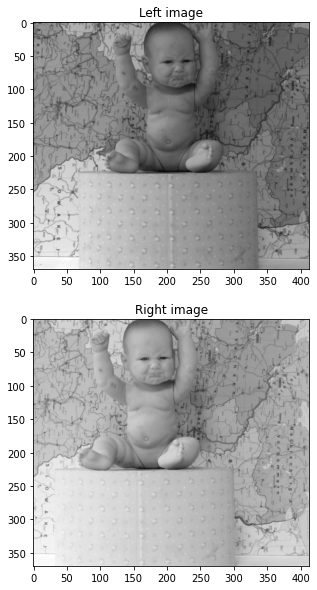

In [ ]:

fig = plt.figure(figsize=(10, 10))

# Adds a subplot at the 1st position
fig.add_subplot(2, 1, 1)
plt.imshow(leftImage, cmap="gray")
plt.title("Left image")
fig.add_subplot(2, 1, 2)
plt.imshow(rightImage, cmap="gray")
plt.title("Right image")
plt.show()

In [ ]:
disparityImage = findDisparityImage(leftImage, rightImage, 3, 64)*3



Processing.. 99% complete

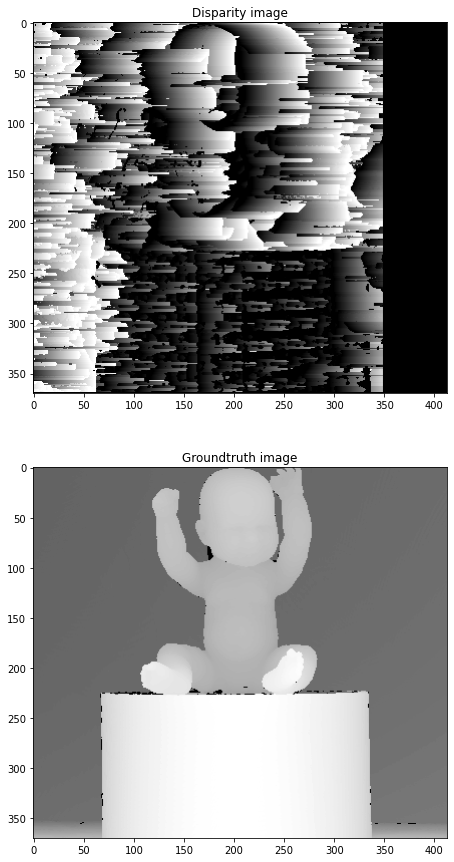

In [ ]:
fig = plt.figure(figsize=(15, 15))
fig.add_subplot(2, 1, 1)
plt.imshow(disparityImage, cmap="gray")
plt.title("Disparity image")
fig.add_subplot(2, 1, 2)
plt.imshow(groundTruthImage, cmap="gray")
plt.title("Groundtruth image")
plt.show()

Tính ảnh Disparity sử dụng giải thuật SSD

In [ ]:
def findDisparityImage(leffImage, rightImage, kernelSize, max_disparity):
  h, w = leftImage.shape
  disparity = np.zeros((h, w), np.uint8)

  kernel_half = int(kernelSize / 2)

  for y in range(kernel_half, h - kernel_half):
      print("\rProcessing.. %d%% complete" % (y / (h - kernel_half) * 100), end="", flush=True)

      for x in range(kernel_half, w - max_disparity):
          best_offset = 0
          prev_ssd = 65534

          for offset in range(max_disparity):
              ssd = 0
              
              for v in range(-kernel_half, kernel_half+1):
                  for u in range(-kernel_half, kernel_half+1):
                      ssd_temp = int(leffImage[y + v, x + u]) - int(rightImage[y + v, (x + u) - offset])
                      ssd += ssd_temp * ssd_temp

              if ssd < prev_ssd:
                  prev_ssd = ssd
                  best_offset = offset

          disparity[y, x] = best_offset 
  return disparity

Tính lỗi RMS cho ảnh kết quả disparity
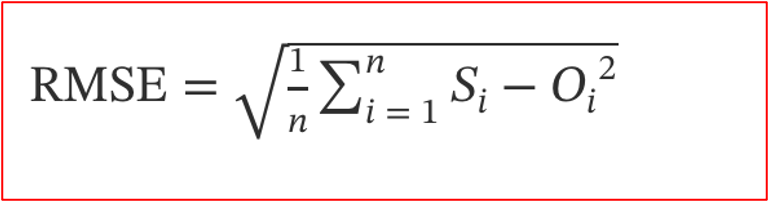

Tinh accuracy

In [ ]:
def computeAccuracy(groundTruthImage, ourDisparity, tolerateError):
  h,w = groundTruthImage.shape
  AD = abs(groundTruthImage - ourDisparity)
  correct = np.count_nonzero(np.abs(AD) < tolerateError)
  
  return float(correct) / (h*w)

In [ ]:
def computeRMS(groundTruthImage, ourDisparity, tolerateError):
  AD = abs(groundTruthImage - ourDisparity)
  AD = AD[np.nonzero(AD >= tolerateError)]
  AD = AD**2
  AD = np.sum(AD)/len(AD)
  return math.sqrt(AD) 


In [ ]:
rms = computeRMS(disparityImage, groundTruthImage, 2)
print(rms)

9.028405543318813


In [ ]:
acc = computeAccuracy(disparityImage, groundTruthImage, 2)
print(acc)

0.0043452653622145145


Tìm Census transform cho ảnh trái và ảnh phải

In [ ]:
def computeCensus(left, right, kernel):
    h, w = left.shape  
    kernel_half = int(kernel / 2)
    shape = (h, w, kernel*kernel-1)

    #Tạo mảng 3D chứa kết quả từ Census Tranform
    left_census = np.zeros(shape,np.uint8)
    right_census = np.zeros(shape,np.uint8)

    for y in range(kernel_half, h - kernel_half):
      #Theo dõi thời gian hoàn thành giải thuật
        print("\rProcessing.. %d%% complete" % (y / (h - kernel_half) * 100), end="", flush=True)

        for x in range(kernel_half, w - kernel_half):

            index = 0
            for v in range(-kernel_half, kernel_half+1):
                for u in range(-kernel_half, kernel_half+1):
                    if (not (v == 0 and u == 0)):

                        if (int(left[y + v, x + u]) >= int(left[y + 0, x + 0])):
                            left_census[y,x,index] = 1
                        else:
                            left_census[y, x, index] = 0

                        if (int(right[y + v, (x + u)]) >= int(right[y + 0, (x + 0)])):
                            right_census[y,x,index] = 1
                        else:
                            right_census[y, x, index] = 0

                        index = index + 1


    return left_census, right_census

In [ ]:
left_census, right_census = computeCensus(leftImage, rightImage, 3)

Processing.. 99% complete

In [ ]:
print(left_census.shape)

(370, 413, 8)


In [ ]:
def visualizeCensus(census_image, kernel):
    kernel_half = int(kernel / 2)

    h,w,d = census_image.shape

    # Depth (or disparity) map
    image = np.zeros((h, w), np.uint8)

    for y in range(kernel_half, h - kernel_half):
        for x in range(kernel_half, w - kernel_half):
            sum = 0
            for c in range(0,kernel*kernel-1):
                value = census_image[y,x,c]
                if(value == 1):
                    sum = sum + pow(2,c)
            image[y,x] = sum
    return image


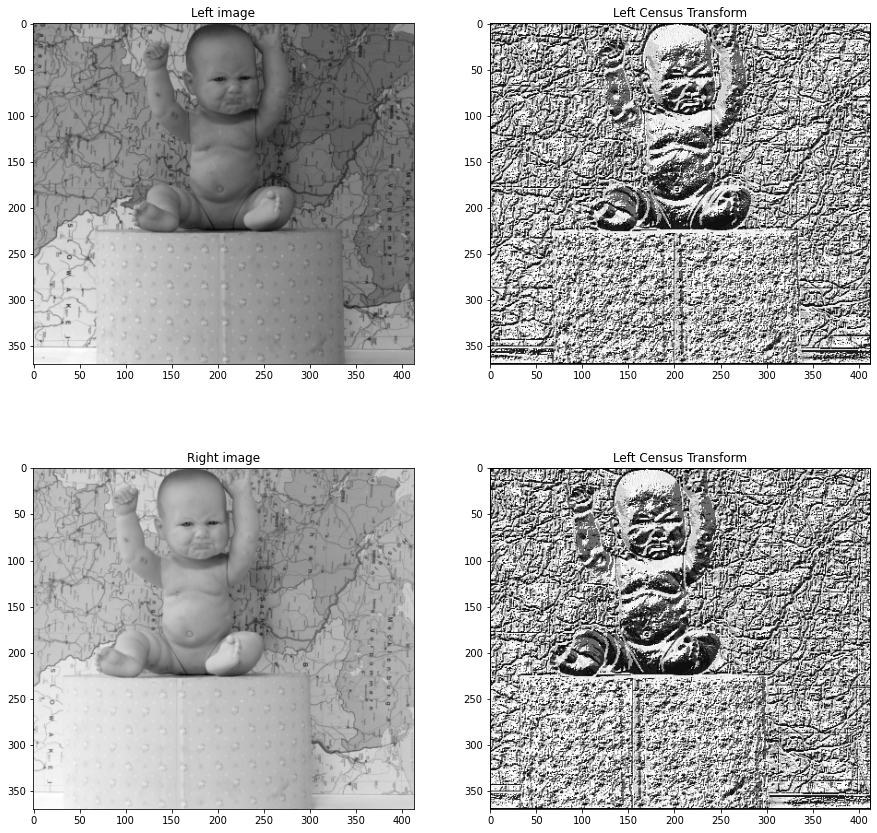

In [ ]:
left_census_v = visualizeCensus(left_census, 3)
right_census_v = visualizeCensus(right_census, 3)

fig,ax = plt.subplots(2,2,figsize = (15,15))

ax[0,0].imshow(leftImage, cmap = 'gray')
ax[0,0].set_title("Left image")

ax[0,1].imshow(left_census_v, cmap = 'gray')
ax[0,1].set_title("Left Census Transform")

ax[1,0].imshow(rightImage, cmap = 'gray')
ax[1,0].set_title("Right image")

ax[1,1].imshow(right_census_v, cmap = 'gray')
ax[1,1].set_title("Left Census Transform")


plt.show()

In [ ]:
def findDisparityByCensus(left_census, right_census, kernelSize, max_disparity):
  h, w, c = left_census.shape
  disparity = np.zeros((h, w), np.uint8)

  kernel_half = int(kernelSize / 2)

  for y in range(kernel_half, h - kernel_half):
      print("\rProcessing.. %d%% complete" % (y / (h - kernel_half) * 100), end="", flush=True)

      for x in range(kernel_half, w - max_disparity):
          best_offset = 0
          prev_hamming_distance = 65534

          for offset in range(max_disparity):
              sum_hamming_distance = 0
              for v in range(-kernel_half, kernel_half+1):
                  for u in range(-kernel_half, kernel_half+1):

                      for c in range(0,kernelSize**2-1):
                         l_c = left_census[y+v, x+u, c]
                         r_c = right_census[y+v, x+u-offset, c]
                         if(l_c != r_c):
                           sum_hamming_distance = sum_hamming_distance + 1

              if sum_hamming_distance < prev_hamming_distance:
                  prev_hamming_distance = sum_hamming_distance
                  best_offset = offset

          disparity[y, x] = best_offset 

  return disparity

In [ ]:
dis_census = findDisparityByCensus(left_census, right_census, 3, 64)*3


Processing.. 99% complete

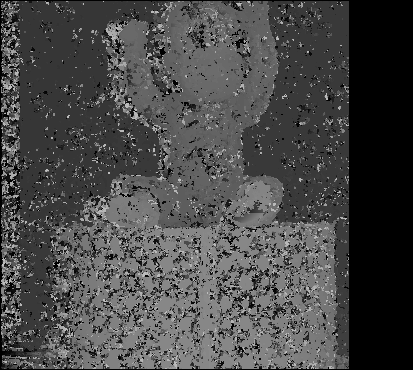

In [ ]:
cv2_imshow(dis_census)

In [ ]:
acc = computeAccuracy(dis_census, groundTruthImage, 2)
print(acc)

0.27130423401609843


In [ ]:
rms = computeRMS(dis_census, groundTruthImage, 2)
print(rms)

len(AD) 111352
np.sum(AD) 7779977
8.358727085239916


************************************************************************************

************************************************************************************

************************************************************************************

************************************************************************************

************************************************************************************

************************************************************************************